Nick Garcia and Dillan Andrews

In [2]:
#https://www.kaggle.com/datasets/brsahan/genomic-data-for-cancer

In [48]:
import numpy as np #importing all necessary libraries for the KNN algorithm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ( train_test_split, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix)
#printing out a title regarding the database
print("=" * 60)
print("Cancer Diagnosis Prediction")
print("=" * 60)
print()

Cancer Diagnosis Prediction



In [4]:
#importing the correct file/dataset into Google Colab
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('gene_expression.csv')
df.head()#displaying the table of the dataset

Saving gene_expression.csv to gene_expression.csv


,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [5]:
df.isnull().sum()# checking for any null values

,0
Gene One,0
Gene Two,0
Cancer Present,0


In [ ]:
#There was no need for any other feature engineering
#The cancer present column was already label encoded

In [7]:
print(f"Cancer Genes: {df.shape[0]}")
print(f"Cancer Features: {df.shape[1] - 1}")

print()
#the shape code will display both the row count
#It will display the row count count of the x variable
#It will display the total outcome from the target variable

Cancer Genes: 3000
Cancer Features: 2



In [8]:
print("First 10 rows of the dataset:")
print(df.head(10).to_string(index=False))
print()
#Double checking the first 10 rows

First 10 rows of the dataset:
 Gene One  Gene Two  Cancer Present
      4.3       3.9               1
      2.5       6.3               0
      5.7       3.9               1
      6.1       6.2               0
      7.4       3.4               1
      3.4       7.5               0
      3.1       6.8               0
      6.3       4.9               1
      5.5       8.6               0
      7.7       3.5               1



In [22]:
print("Exploring the Data")
print("-" * 40)
print('Average values per gene variety:')
print(df.groupby('Cancer Present').mean().round(1))
print()

plt.figure(figsize=(7, 5))
#This will display the mean for both genes and group it by cancer being present


Exploring the Data
----------------------------------------
Average values per gene variety:
                Gene One  Gene Two
Cancer Present                    
0                    4.6       6.6
1                    6.6       4.2



<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

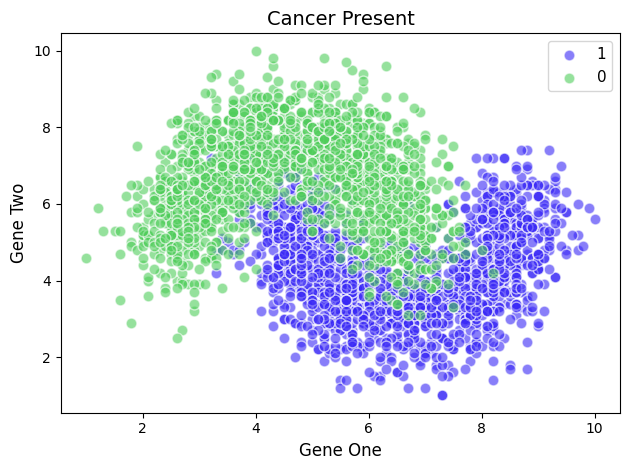

 -> Scatter plot saved as 'Cancer_Scatter.png'
 -> Look for two distinct clusters. if they're well-seperated,
 KNN should perform well



In [30]:
#setting up the scatter plot with color, point size, transparency, and x/y values
colors = {1: "#3928F6", 0: "#4FCD5A" }
for gene_type, color in colors.items():
  subset= df[df['Cancer Present']== gene_type]
  plt.scatter(
      subset['Gene One'],
      subset['Gene Two'],
      c=color,
      label=gene_type,
      alpha=0.6,
      edgecolors='w',
      s=60
  )
#setting up the size of each label and layout
plt.xlabel('Gene One', fontsize = 12)
plt.ylabel('Gene Two', fontsize = 12)
plt.title('Cancer Present', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('Cancer_Scatter.png', dpi=150)
plt.show()
#prints a message at the end to confirm the code is run correctly
print(" -> Scatter plot saved as 'Cancer_Scatter.png'")
print(" -> Look for two distinct clusters. if they're well-seperated,")
print(" KNN should perform well")
print()


In [31]:
#the will seprate each of the feautures or variables from the actual labels
#X will be the input data
#Y will be the label we want to predict
print("Preparing the Data")
print("-" * 40)

x = df.drop('Cancer Present', axis =1)
y = df['Cancer Present']

print(f"Features (X) shape: {x.shape} ")
print(f"Labels (Y) shape: {y.shape}")
print()

Preparing the Data
----------------------------------------
Features (X) shape: (3000, 2) 
Labels (Y) shape: (3000,)



In [32]:
#This will split the data into a testing set and a training set
#0.2 means it will split 20% of the data into the data set and seperate 80% of it
#random state makes it repoducible
#stratify will balance out the outcome(y)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#prints the final samples
print(f"Training Samples: {x_train.shape[0]}")
print(f"Testing Samples: {x_test.shape[0]}")
print()

Training Samples: 2400
Testing Samples: 600



In [35]:
#scaler transforms the inputs so it has a mean and a std
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

print("Features have been scaled using StandardScaler.")
print("  -> Training Data: fit_transform (learn + scale)")
print("  -> Testing Data: transoform only ( scale using same parameters)")
print()

Features have been scaled using StandardScaler.
  -> Training Data: fit_transform (learn + scale)
  -> Testing Data: transoform only ( scale using same parameters)



In [37]:
#Starts training the data with a classifier of 5
print("Training the KNN Model")
print("-" * 40)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)

print("Model trained with K=5 neighbors.")
print()
# this will calculate the distance and take a vote based of the classifier being 5
y_pred = knn.predict(x_test_scaled)

print("Predictions made on the test set.")
print()

Training the KNN Model
----------------------------------------
Model trained with K=5 neighbors.

Predictions made on the test set.



In [40]:
#This will evaluate the model by calculating:
# accuracy, precision, recall, and f1-score percentages
#This will will combine all to get a overall accuracy
print("Evaluating the Model")
print("-" * 40)

accuracy = accuracy_score(y_test, y_pred)

print(f"Overal Accuracy: {accuracy:.2%}")
print()

Evaluating the Model
----------------------------------------
Overal Accuracy: 93.67%



Detailed Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       300
           1       0.93      0.95      0.94       300

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



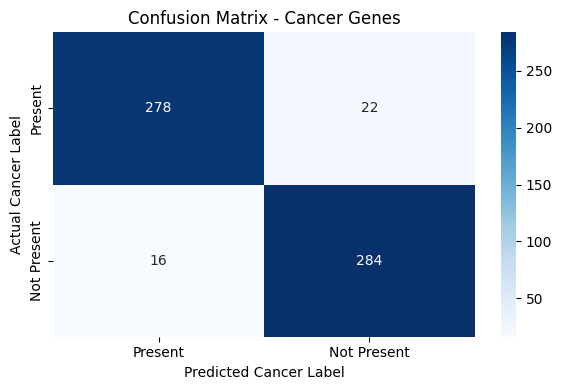

 -> Confusion matrix saved as 'Cancer_Confusion.png



In [42]:

print("Detailed Classification Report: ")
print(classification_report(y_test, y_pred))
#this will give you each individual % of precision, recall, f1-score
#along with the macro and wighted avg
cm = confusion_matrix(y_test, y_pred)
#displays a heatmap with the cm we calculated
#displaying numbers in each box
#displaying numbers as int or the color scheme
#displaying each label
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Present', 'Not Present'],
    yticklabels=['Present', 'Not Present']
)
plt.xlabel('Predicted Cancer Label')
plt.ylabel('Actual Cancer Label')
plt.title('Confusion Matrix - Cancer Genes')
plt.tight_layout()
plt.savefig('Cancer_Confusion.png', dpi=150)
plt.show()

print(" -> Confusion matrix saved as 'Cancer_Confusion.png")
print()

Finding the Best K
----------------------------------------


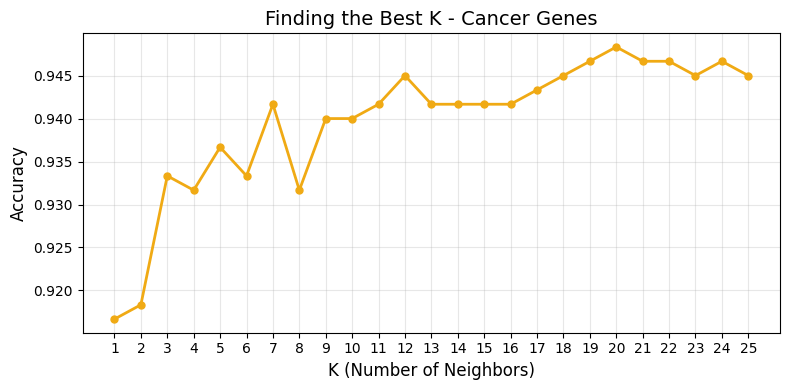

 -> Best K = 20
 -> Best Accuracy = 94.83%
 -> Chart saved as 'Cancer_best_k.png



In [44]:
print("Finding the Best K")
print("-" * 40)
#We will be testing the k-values from 1-25
k_values = range(1, 26)
accuracies = []
#this will create a new model, train it, predict, and calculate the accuracy
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(x_train_scaled, y_train)

    pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
#making a plot chart for K vs accuracy
#displaying all chart elements and labels
plt.figure(figsize = (8,4))
plt.plot(
    k_values,
    accuracies,
    marker='o',
    color="#f0aa14",
    linewidth = 2,
    markersize=5
)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Best K - Cancer Genes', fontsize=14)
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Cancer_best_k.png', dpi=150)
plt.show()

best_k = list(k_values)[np.argmax(accuracies)]
best_accuracy = max(accuracies)
#printing out the best k and the accuracy
print(f" -> Best K = {best_k}")
print(f" -> Best Accuracy = {best_accuracy:.2%}")
print(f" -> Chart saved as 'Cancer_best_k.png")
print()

In [47]:
#we will use our trained model to predict and classify a new model for if the cancer is present or not
print("Cancer Predictability")
print("-" * 40)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train_scaled, y_train)
#Making new values for each gene around the original values of the dataset
new_cancer = pd.DataFrame({
    'Gene One': [5.6],
    'Gene Two': [4.9]
})

print(" New Gene Data:")
print(new_cancer.to_string(index=False))
print()
#we scale the new cancer values with the original scaler we trained
#it will make a final prediction and print the prediction %
new_cancer_scaled = scaler.transform(new_cancer)

prediction = final_model.predict(new_cancer_scaled)
print(f"Predicted Variety: {prediction[0]}")

probabilities = final_model.predict_proba(new_cancer_scaled)

print("Confidence scores:")
for cancer_name, prob in zip(final_model.classes_, probabilities[0]):
  bar = '█' * int(prob * 30)
  print(f" {cancer_name:15} {prob:6.1%} {bar}")

print()
print("=" * 60)
print("  DONE! You've completed the Cancer Probability KNN example")
print("=" * 60)

Predicting a New Seed
----------------------------------------
 New Gene Data:
 Gene One  Gene Two
      5.6       4.9

Predicted Variety: 1
Confidence scores:
               0  30.0% █████████
               1  70.0% █████████████████████

  DONE! You've completed the Cancer Probability KNN example


The dataset we decided to use is cancer dataset. It has gene expressions that tell you if the patient has cancer or not. There are only two genes and based on the genes given it will tell you if the cancer is present or not. We used a algorithm called K-Nearest Neighbors, this algotithm trains the current data by ensuring the datas usability, which was 93%, along with detecting if the data is true or false. We test and train the model by determining the mean of each gene while being grouped by the cancer class. The way it is trains itself it calculates the original distance of all the samples given and it will find the 5 closest ones and will take a majority vote among those 5. We chart the data multiple times to ensure the usuability again and at the end we use what we trained and test to make a predictive model where inputt a random value. Those random values will tell you the percentages if the cancer is present or not. As seen in the last code and the values we inputted. There is a 70% the cancer is present and 30% is not.